## Aşama 0 — Ortam Hazırlığı ve Colab Düzeni

Çalışma Google Colab ortamında yürütülmüştür. Kullanılan derin öğrenme kütüphanesi TensorFlow’dur ve ortamda TensorFlow 2.20.0 sürümü algılanmıştır.

GPU kontrolü yapıldığında herhangi bir GPU aygıtı algılanmamıştır. Bu nedenle eğitim işlemleri CPU üzerinde gerçekleştirilecektir. LSTM modellerinde GPU kullanımı özellikle büyük veri setlerinde, uzun metin dizilerinde ve yüksek epoch sayılarında eğitim süresini azaltabilir. Ancak bu çalışmada yönetilebilir büyüklükte bir metin sınıflandırma veri seti kullanılacağı için CPU ile ilerlemek mümkündür.

Tekrar üretilebilirlik için rastgelelik kontrolü yapılmış ve seed değeri 42 olarak belirlenmiştir. Python random, NumPy ve TensorFlow için aynı seed değeri atanmıştır. Böylece veri bölme, model başlangıç ağırlıkları ve bazı rastgele işlemlerin mümkün olduğunca benzer sonuçlar üretmesi amaçlanmıştır.

### Kullanılan Ortam Bilgileri

| Özellik | Değer |
|---|---|
| Çalışma ortamı | Google Colab |
| Derin öğrenme kütüphanesi | TensorFlow |
| TensorFlow sürümü | 2.20.0 |
| GPU durumu | Algılanmadı |
| Seed değeri | 42 |

### Deney Günlüğü Planı

Her aşamada aşağıdaki bilgiler kaydedilecektir:

- Yapılan işlem
- İşlemin amacı
- Üretilen ara çıktı
- Gözlenen sonuç
- Teknik yorum

Bu sayede model yalnızca çalıştırılmayacak, aynı zamanda veri hazırlama, eğitim ve değerlendirme süreci kontrollü biçimde izlenecektir.

### Bulut Ortamında Çalışmanın Avantajları ve Sınırlılıkları

Google Colab, kurulum gerektirmeden Python, TensorFlow ve temel veri bilimi kütüphanelerini kullanma imkânı sağlar. Ayrıca GPU/TPU desteği sunabildiği için derin öğrenme eğitimlerinde avantaj sağlayabilir.

Bununla birlikte Colab oturumları geçici olabilir. Oturum kapanırsa RAM’deki değişkenler silinebilir. Bu nedenle notebook dosyası düzenli kaydedilmeli, önemli çıktılar not edilmeli ve deneylerde kullanılan seed, hiperparametreler ve veri bölme oranları rapora yazılmalıdır.

## Aşama 1 — Kütüphanelerin Belirlenmesi ve Algılatılması
Bu aşamada metin işleme, model oluşturma, eğitim ve değerlendirme süreçlerinde kullanılacak kütüphaneler belirlenmiş ve çalışma ortamına yüklenmiştir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SimpleRNN, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

print("Tüm kütüphaneler başarıyla import edildi.")

Tüm kütüphaneler başarıyla import edildi.


## Kullanılan Kütüphaneler ve Görevleri

| Kütüphane | Görevi | Bu Çalışmadaki Kullanım Amacı |
|---|---|---|
| NumPy | Sayısal işlemler | Dizi işlemleri ve sayısal veri yönetimi |
| Pandas | Veri analizi | Veri inceleme ve tablo işlemleri |
| Matplotlib | Grafik çizimi | Eğitim grafiklerinin ve veri dağılımlarının görselleştirilmesi |
| TensorFlow / Keras | Derin öğrenme altyapısı | LSTM tabanlı model oluşturma ve eğitme |
| imdb dataset | Hazır metin veri seti | Film yorumları üzerinden duygu analizi |
| pad_sequences | Dizi uzunluklarını eşitleme | Metinleri sabit uzunlukta modele verme |
| Sequential | Model oluşturma | Katmanların sıralı biçimde kurulması |
| Embedding | Kelime vektör temsili | Kelimeleri sayısal yoğun vektörlere dönüştürme |
| LSTM | Sıralı veri öğrenimi | Metin dizilerindeki bağlam ilişkilerini öğrenme |
| Dense | Tam bağlı katman | Sınıflandırma çıktısı üretme |
| Dropout | Aşırı öğrenmeyi azaltma | Overfitting riskini düşürme |
| EarlyStopping | Eğitimi kontrol etme | Validation başarısı düşerse eğitimi durdurma |
| Scikit-learn metrics | Model değerlendirme | Precision, recall, F1-score ve confusion matrix üretme |

## Derin Öğrenme Çerçevesi Seçimi

Bu çalışmada TensorFlow/Keras tercih edilmiştir. Bunun temel nedenleri:

- Google Colab ile uyumlu çalışması
- LSTM katmanlarını hazır ve stabil biçimde sunması
- Metin işleme araçlarının kolay kullanılabilmesi
- Eğitim sürecinin kolay izlenebilmesi
- Akademik örnek ve dokümantasyon desteğinin güçlü olması

Keras yapısı sayesinde model katmanları daha okunabilir biçimde oluşturulabilmektedir. Bu durum deneysel çalışmalar sırasında mimari değişikliklerini kolaylaştırmaktadır.

## Sürüm Uyumluluğunun Önemi

Derin öğrenme kütüphanelerinde sürüm farklılıkları tokenizer davranışını, padding işlemlerini, katman parametrelerini ve çıktı biçimlerini değiştirebilir. Bu nedenle kullanılan TensorFlow sürümünün raporda belirtilmesi tekrar üretilebilirlik açısından önemlidir.

## Import Doğrulama Sonucu

Tüm gerekli kütüphaneler başarıyla import edilmiştir ve çalışma ortamı LSTM modeli geliştirmeye hazır hale getirilmiştir.

# Aşama 2 — Veri Setinin Bulunması ve Yapısının İncelenmesi
## Veri Setine Erişim

Bu çalışmada kullanılan veri seti TensorFlow/Keras içerisinde hazır bulunan IMDB Movie Reviews veri setidir.

Veri setine aşağıdaki yöntem ile erişilmiştir:

```python
from tensorflow.keras.datasets import imdb

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)
```

Veri seti TensorFlow veri deposundan otomatik olarak indirilmiştir.

Resmî kaynak:
- https://keras.io/api/datasets/imdb/

Ek kaynak (Kaggle):
- https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Bu veri seti:
- film yorumlarından oluşmaktadır,
- pozitif ve negatif etiketler içermektedir,
- binary metin sınıflandırma problemleri için yaygın olarak kullanılmaktadır.

Veri setinin tercih edilme nedenleri:
- akademik çalışmalarda yaygın kullanılması,
- duygu analizi problemleri için uygun olması,
- LSTM tabanlı sıralı modelleri test etmek için uygun yapı sunmasıdır.

In [2]:
# IMDB veri setini yükleme

vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Eğitim veri sayısı:", len(X_train))
print("Test veri sayısı:", len(X_test))

print("\nİlk yorum örneği:")
print(X_train[0])

print("\nİlk yorum etiketi:")
print(y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Eğitim veri sayısı: 25000
Test veri sayısı: 25000

İlk yorum örneği:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16,

In [3]:
# Sınıf dağılımı

unique, counts = np.unique(y_train, return_counts=True)

print("Sınıf dağılımı:")
for label, count in zip(unique, counts):
    print(f"Sınıf {label}: {count} örnek")

Sınıf dağılımı:
Sınıf 0: 12500 örnek
Sınıf 1: 12500 örnek


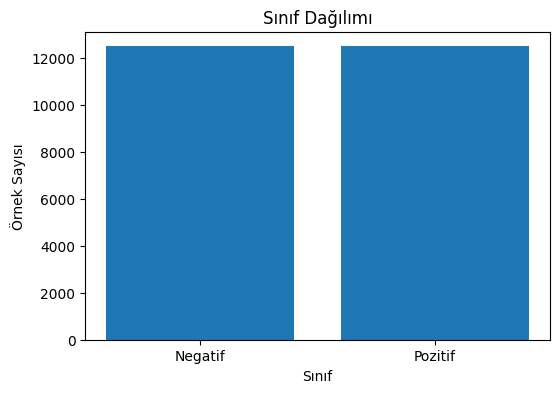

In [4]:
# Sınıf dağılımı görselleştirme

labels = ["Negatif", "Pozitif"]
counts = [12500, 12500]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.title("Sınıf Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Örnek Sayısı")
plt.show()

Sınıf dağılımı grafiği incelendiğinde negatif ve pozitif yorum sayılarının eşit olduğu görülmektedir. Bu durum veri setinin dengeli olduğunu göstermektedir.

Minimum uzunluk: 11
Maksimum uzunluk: 2494
Ortalama uzunluk: 238.71364


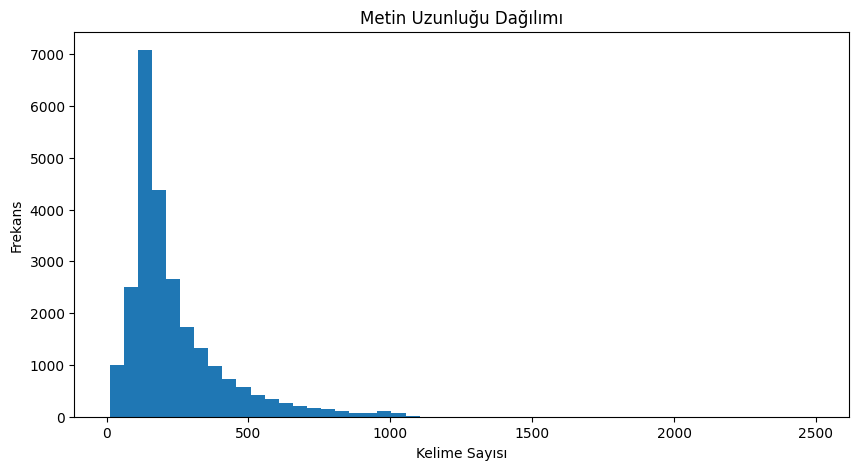

In [5]:
# Metin uzunluklarını inceleme

text_lengths = [len(text) for text in X_train]

print("Minimum uzunluk:", min(text_lengths))
print("Maksimum uzunluk:", max(text_lengths))
print("Ortalama uzunluk:", np.mean(text_lengths))

plt.figure(figsize=(10,5))
plt.hist(text_lengths, bins=50)
plt.title("Metin Uzunluğu Dağılımı")
plt.xlabel("Kelime Sayısı")
plt.ylabel("Frekans")
plt.show()

## Veri Seti İncelemesi

Bu çalışmada IMDB Movie Reviews veri seti kullanılmıştır. Veri seti film yorumlarından oluşmaktadır ve amaç yorumun pozitif mi yoksa negatif mi olduğunu tahmin etmektir.

Veri seti toplamda 50.000 örnek içermektedir:

- 25.000 eğitim verisi
- 25.000 test verisi

Problem türü binary (iki sınıflı) metin sınıflandırmadır.

## Sınıf Dağılımı

Veri setinde sınıf dağılımı dengelidir:

| Sınıf | Anlamı | Örnek Sayısı |
|---|---|---|
| 0 | Negatif yorum | 12500 |
| 1 | Pozitif yorum | 12500 |

Sınıfların eşit sayıda olması model değerlendirmesi açısından avantaj sağlamaktadır. Böylece modelin yalnızca çoğunluk sınıfına yönelerek yüksek accuracy elde etme riski azalmaktadır.

## Metin Uzunluğu Analizi

Metin uzunlukları incelendiğinde:

- Minimum uzunluk: 11 kelime
- Maksimum uzunluk: 2494 kelime
- Ortalama uzunluk: yaklaşık 239 kelime

Veri setinde çok kısa ve çok uzun yorumların birlikte bulunduğu gözlenmiştir. Bu durum LSTM modelleri açısından önemlidir çünkü:

- Çok kısa metinlerde yeterli bağlam bulunmayabilir.
- Çok uzun metinlerde ise eğitim maliyeti artabilir ve gereksiz bilgi modele yük olabilir.

Bu nedenle ilerleyen aşamalarda uygun bir maksimum dizi uzunluğu belirlenmesi gerekecektir.

## Veri Kalitesi Gözlemleri

İlk incelemede veri setinde eksik kayıt veya boş metin problemi gözlenmemiştir. Ancak farklı uzunluklara sahip metinler bulunduğu için padding ve truncation işlemlerine ihtiyaç duyulacaktır.

Ayrıca veri seti sayısal indeksler biçiminde tutulmaktadır. Bu indeksler gerçek kelimeleri temsil etmektedir ve doğrudan modele verilmeden önce uygun ön işleme adımlarıyla düzenlenecektir.

# Aşama 3 — LSTM Kavramının Araştırılması
## LSTM Nedir?

LSTM (Long Short-Term Memory), sıralı veriler üzerinde öğrenme yapabilen özel bir Recurrent Neural Network (RNN) türüdür. Özellikle metin, zaman serisi ve konuşma gibi sıraya bağlı verilerde kullanılır.

Klasik tam bağlı yapay sinir ağları girişler arasındaki sıra ilişkisini dikkate almaz. Ancak metin verilerinde kelimelerin sırası anlam açısından kritik öneme sahiptir. LSTM mimarisi bu sıralı yapıyı koruyarak önceki bilgileri hafızasında tutabilir.

LSTM’in temel amacı uzun bağımlılık problemini çözmektir. Standart RNN modellerinde uzun dizilerde önceki bilgiler zamanla kaybolabilir. LSTM ise özel kapı mekanizmaları sayesinde önemli bilgileri koruyabilir ve gereksiz bilgileri unutabilir.

## LSTM Kapı Mekanizmaları

LSTM yapısında üç temel kapı bulunur:

### Forget Gate
Önceki bilgilerden hangilerinin unutulacağına karar verir.

### Input Gate
Yeni gelen bilginin ne kadarının hafızaya ekleneceğini belirler.

### Output Gate
Hangi bilginin çıktı olarak kullanılacağını kontrol eder.

Bu yapı sayesinde LSTM uzun metinlerde bağlam bilgisini klasik RNN yapılarına göre daha başarılı şekilde koruyabilir.

## LSTM ve RNN Farkı

Basit RNN modelleri uzun dizilerde vanishing gradient problemi yaşayabilir. Bu durum modelin eski bilgileri unutmasına neden olur.

LSTM modelleri ise hücre durumu (cell state) ve kapı mekanizmaları sayesinde uzun süreli bağımlılıkları daha iyi öğrenebilir.

## GRU ile Karşılaştırma

GRU (Gated Recurrent Unit), LSTM’e benzer ancak daha sade bir yapıya sahip alternatif bir sıralı veri modelidir.

- LSTM daha karmaşık yapıdadır.
- GRU daha az parametre içerir.
- GRU bazı durumlarda daha hızlı eğitilebilir.
- LSTM uzun bağlam gerektiren problemlerde avantaj sağlayabilir.

In [6]:
from tensorflow.keras.utils import plot_model

example_model = Sequential([
    Embedding(input_dim=10000, output_dim=32),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

example_model.build(input_shape=(None, 200))

example_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

## Örnek LSTM Mimarisinin İncelenmesi

Kurulan örnek yapı üç temel katmandan oluşmaktadır:

| Katman | Görevi |
|---|---|
| Embedding | Kelimeleri yoğun vektörlere dönüştürür |
| LSTM | Sıralı bağımlılıkları öğrenir |
| Dense | Son sınıflandırma çıktısını üretir |

### Embedding Katmanı

Embedding katmanı, kelimeleri doğrudan sayı olarak kullanmak yerine anlamsal ilişkileri temsil eden yoğun vektörlere dönüştürmektedir.

Bu modelde:
- vocabulary size = 10000
- embedding boyutu = 32

olarak seçilmiştir.

Embedding katmanı sayesinde benzer anlam taşıyan kelimeler vektör uzayında birbirine yakın temsil edilebilir.

### LSTM Katmanı

LSTM katmanı 32 birimden oluşmaktadır. Bu katman metin içindeki sıralı bağımlılıkları öğrenmeye çalışır.

LSTM yapısı:
- geçmiş bilgileri tutabilir,
- gereksiz bilgileri unutabilir,
- önemli bağlamı koruyabilir.

Bu nedenle metin sınıflandırma problemlerinde klasik tam bağlı ağlara göre daha başarılı sonuçlar verebilir.

### Dense Çıkış Katmanı

Son katmanda sigmoid aktivasyon fonksiyonu kullanılmıştır. Bunun nedeni problemin binary sınıflandırma problemi olmasıdır.

Çıkış:
- 0 → negatif yorum
- 1 → pozitif yorum

anlamına gelmektedir.

### Parametre Sayısı Yorumu

Model toplam 328.353 adet eğitilebilir parametre içermektedir.

Parametre sayısının artması modelin öğrenme kapasitesini artırabilir. Ancak aşırı büyük modeller:
- daha fazla eğitim süresi,
- daha yüksek bellek kullanımı,
- overfitting riski

oluşturabilir.

# Aşama 4 — Metin Verisinin Modele Hazırlanması

In [7]:
# Maksimum dizi uzunluğu belirleme

max_length = 200

X_train_padded = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Padding sonrası eğitim veri boyutu:", X_train_padded.shape)
print("Padding sonrası test veri boyutu:", X_test_padded.shape)

print("\nİlk padding uygulanmış örnek:")
print(X_train_padded[0])

Padding sonrası eğitim veri boyutu: (25000, 200)
Padding sonrası test veri boyutu: (25000, 200)

İlk padding uygulanmış örnek:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141 

## Ön İşleme Kararları

IMDB veri seti Keras içinde hazır sayısal indekslenmiş biçimde geldiği için klasik metin temizleme adımları ayrıca uygulanmamıştır. Metinler doğrudan kelime indeksleri dizisi olarak temsil edilmektedir.

Bu çalışmada alınan ön işleme kararları:

| Karar | Açıklama |
|---|---|
| Vocabulary size | En sık geçen 10.000 kelime kullanılmıştır |
| Maksimum dizi uzunluğu | 200 kelime seçilmiştir |
| Padding yöntemi | post-padding |
| Truncation yöntemi | post-truncating |
| Kelime temsili | Embedding katmanı |
| OOV yaklaşımı | En sık 10.000 kelime dışındaki kelimeler veri seti yüklenirken dışarıda bırakılmıştır |

## Maksimum Dizi Uzunluğu Seçimi

Veri setinde ortalama yorum uzunluğu yaklaşık 239 kelimedir. Bu nedenle maksimum dizi uzunluğu 200 olarak seçilmiştir.

Bu seçimle:
- çok kısa yorumlar sıfırlarla tamamlanır,
- çok uzun yorumlar 200 kelimeye kırpılır,
- model giriş boyutu sabit hale getirilir,
- eğitim maliyeti kontrol altında tutulur.

Dizi uzunluğu çok kısa seçilirse yorumun anlamlı kısmı kaybedilebilir. Çok uzun seçilirse eğitim süresi ve bellek kullanımı artabilir.

## Padding ve Truncation Yorumu

LSTM modelleri aynı batch içindeki verilerin aynı uzunlukta olmasını bekler. Bu nedenle farklı uzunluktaki yorumlar `pad_sequences` işlemiyle 200 uzunluğa getirilmiştir.

Padding sonrası eğitim verisi boyutu:

```text
(25000, 200)

# Aşama 5 — Train / Validation / Test Ayrımı

In [8]:
# Eğitim verisinden validation kümesi ayırma

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_padded,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

print("Final eğitim veri boyutu:", X_train_final.shape)
print("Validation veri boyutu:", X_val.shape)
print("Test veri boyutu:", X_test_padded.shape)

print("\nEğitim sınıf dağılımı:", np.unique(y_train_final, return_counts=True))
print("Validation sınıf dağılımı:", np.unique(y_val, return_counts=True))
print("Test sınıf dağılımı:", np.unique(y_test, return_counts=True))

Final eğitim veri boyutu: (20000, 200)
Validation veri boyutu: (5000, 200)
Test veri boyutu: (25000, 200)

Eğitim sınıf dağılımı: (array([0, 1]), array([10000, 10000]))
Validation sınıf dağılımı: (array([0, 1]), array([2500, 2500]))
Test sınıf dağılımı: (array([0, 1]), array([12500, 12500]))


## Veri Kümesinin Bölünmesi

Makine öğrenmesi ve derin öğrenme çalışmalarında veri setinin eğitim, doğrulama ve test kümelerine ayrılması büyük önem taşımaktadır.

Bu çalışmada:

- Eğitim verisi → modelin öğrenmesi için
- Validation verisi → eğitim sırasında performansı izlemek için
- Test verisi → modelin daha önce görmediği veriler üzerindeki gerçek başarısını ölçmek için

kullanılmıştır.

## Bölme Oranı

Bu çalışmada:

- Eğitim verisinin %80’i final training kümesi
- Eğitim verisinin %20’si validation kümesi

olarak ayrılmıştır.

Keras veri seti içinde ayrı verilen test kümesi ayrıca korunmuştur.

## Stratified Split Kullanımı

Veri bölme işlemi sırasında `stratify` kullanılmıştır. Bunun nedeni sınıf dağılımını her alt kümede korumaktır.

Böylece:
- eğitim,
- validation,
- test

kümelerinde pozitif ve negatif yorum oranları dengeli tutulmuştur.

Sınıf dağılımının korunması özellikle sınıf dengesizliği bulunan problemlerde kritik önem taşımaktadır.

## Veri Sızıntısı Riski

Veri sızıntısı (data leakage), aynı örneğin birden fazla veri kümesinde bulunması veya test bilgisinin eğitim sırasında modele dolaylı biçimde aktarılması durumudur.

Bu çalışmada:
- validation kümesi eğitim verisinden ayrılmış,
- test verisi eğitim sürecine dahil edilmemiş,
- veri kümeleri birbirinden bağımsız tutulmuştur.

Bu yaklaşım model performansının daha gerçekçi ölçülmesini sağlamaktadır.

## Validation ve Test Arasındaki Fark

Validation verisi eğitim sırasında model davranışını izlemek için kullanılır. Örneğin:
- early stopping,
- hiperparametre seçimi,
- epoch takibi

gibi işlemler validation verisi üzerinden yapılabilir.

Test verisi ise yalnızca en sonunda kullanılır. Böylece modelin gerçek genelleme başarısı ölçülür.

## Bölme Sonuçları

| Veri Kümesi | Boyut | Negatif | Pozitif |
|---|---:|---:|---:|
| Eğitim | 20000 | 10000 | 10000 |
| Validation | 5000 | 2500 | 2500 |
| Test | 25000 | 12500 | 12500 |

Sonuçlar incelendiğinde veri kümelerinde sınıf dengesinin korunduğu görülmektedir. Stratified split kullanıldığı için her veri kümesinde pozitif ve negatif yorum oranları eşit tutulmuştur.

Bu yaklaşım modelin daha dengeli öğrenmesini ve performans metriklerinin daha güvenilir değerlendirilmesini sağlamaktadır.

# Aşama 6 — LSTM Mimarisinin Planlanması ve Kurdurulması

In [9]:
# Temel LSTM modeli

model_lstm_1 = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    LSTM(
        64,
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    Dense(1, activation='sigmoid')
])

model_lstm_1.build(input_shape=(None, max_length))

model_lstm_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

## LSTM Mimarisinin Açıklaması

Bu aşamada binary metin sınıflandırma problemi için temel bir LSTM modeli kurulmuştur.

Model katmanları:

| Katman | Çıkış Boyutu | Parametre Sayısı | Görevi |
|---|---:|---:|---|
| Embedding | (None, 200, 64) | 640000 | Kelime indekslerini 64 boyutlu vektörlere dönüştürür |
| LSTM | (None, 64) | 33024 | Metindeki sıralı ilişkileri ve bağlam bilgisini öğrenir |
| Dense | (None, 1) | 65 | Pozitif/negatif sınıflandırma çıktısı üretir |

Model toplam 673.089 eğitilebilir parametreye sahiptir.

## Mimari Kararların Gerekçesi

Embedding boyutu 64 seçilmiştir. Bu değer, kelimelerin anlam ilişkilerini temsil etmek için yeterli bir başlangıç kapasitesi sunarken model boyutunu da aşırı artırmamaktadır.

LSTM birim sayısı 64 olarak belirlenmiştir. Bu sayı, metinlerdeki sıralı bağımlılıkları öğrenmek için orta düzey bir kapasite sağlar.

Dropout ve recurrent dropout değerleri 0.3 seçilmiştir. Bu değerler overfitting riskini azaltmak için kullanılmıştır.

Son katmanda sigmoid aktivasyonu kullanılmıştır. Çünkü problem iki sınıflıdır:

- 0: negatif yorum
- 1: pozitif yorum

Bu nedenle kayıp fonksiyonu olarak `binary_crossentropy`, optimizer olarak ise `adam` seçilmiştir.

# Aşama 7 — Model Eğitiminin Başlatılması

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm_1 = model_lstm_1.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 232s 716ms/step - accuracy: 0.5361 - loss: 0.6879 - val_accuracy: 0.5968 - val_loss: 0.6751
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 253s 703ms/step - accuracy: 0.6032 - loss: 0.6670 - val_accuracy: 0.6020 - val_loss: 0.6653
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 226s 721ms/step - accuracy: 0.6379 - loss: 0.6382 - val_accuracy: 0.5772 - val_loss: 0.6699
Epoch 4/5
301/313 ━━━━━━━━━━━━━━━━━━━━ 8s 684ms/step - accuracy: 0.6624 - loss: 0.5988

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_lstm_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Modeli Accuracy Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_lstm_1.history['loss'], label='Training Loss')
plt.plot(history_lstm_1.history['val_loss'], label='Validation Loss')
plt.title('LSTM Modeli Loss Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## İlk Eğitim Sonuçlarının Yorumu

Temel LSTM modeli 5 epoch olarak planlanmış ancak EarlyStopping mekanizması nedeniyle eğitim 4. epoch sonunda durmuştur.

Eğitim sürecinde en iyi validation loss değeri 2. epoch sonunda elde edilmiştir:

| Epoch | Training Accuracy | Validation Accuracy | Training Loss | Validation Loss |
|---|---:|---:|---:|---:|
| 1 | 0.5394 | 0.6386 | 0.6841 | 0.6269 |
| 2 | 0.6760 | 0.7160 | 0.6244 | 0.5941 |
| 3 | 0.6065 | 0.6438 | 0.6495 | 0.6205 |
| 4 | 0.6686 | 0.6712 | 0.5991 | 0.6162 |

Validation accuracy en yüksek 2. epoch’ta yaklaşık %71.60 olarak gözlenmiştir. 3. ve 4. epoch’larda validation loss değerinde iyileşme olmadığı için EarlyStopping devreye girmiştir.

Bu sonuç, modelin öğrenmeye başladığını ancak eğitim sürecinin tam kararlı olmadığını göstermektedir. Training ve validation değerlerinin dalgalanması, modelin hiperparametrelerinin daha fazla denenmesi gerektiğini göstermektedir.

## EarlyStopping Yorumu

EarlyStopping kullanımı overfitting riskini azaltmak için tercih edilmiştir. Validation loss iyileşmediğinde eğitimin durdurulması, modelin eğitim verisini ezberlemeye devam etmesini engelleyebilir.

Bu deneyde `restore_best_weights=True` kullanıldığı için model en iyi validation loss değerini verdiği epoch ağırlıklarına geri döndürülmüştür.

# Aşama 8 — Sonucu Etkileyen Parametrelerin Araştırılması

Bu aşamada LSTM modelinin performansını etkileyebilecek farklı hiperparametreler denenmiştir. Her deneyde mümkün olduğunca sınırlı sayıda parametre değiştirilerek neden-sonuç ilişkisi gözlemlenmeye çalışılmıştır.

Karşılaştırılacak deneyler:

| Deney | Model | Değişiklik |
|---|---|---|
| Deney 1 | Temel LSTM | Embedding 64, LSTM 64, dropout 0.3 |
| Deney 2 | Daha küçük LSTM | Embedding 32, LSTM 32, dropout 0.2 |
| Deney 3 | Bidirectional LSTM | Çift yönlü LSTM kullanımı |

## Deney 2 — Daha Küçük LSTM Modeli

Bu deneyde model karmaşıklığını azaltmanın performansa etkisi incelenmiştir.

Temel modele göre:
- embedding boyutu 64 → 32 düşürülmüştür,
- LSTM birim sayısı 64 → 32 düşürülmüştür,
- dropout değeri 0.3 → 0.2 olarak değiştirilmiştir.

Bu değişikliklerin amacı:
- model boyutunu küçültmek,
- eğitim süresini azaltmak,
- daha düşük parametreli bir yapının genelleme başarısını gözlemlemektir.

Beklenen durum:
- eğitim süresinin azalması,
- model kapasitesinin düşmesi,
- bazı durumlarda daha stabil öğrenme,
- bazı durumlarda ise daha düşük doğruluk oluşmasıdır.

In [ ]:
model_lstm_2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    LSTM(32, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model_lstm_2.build(input_shape=(None, max_length))

model_lstm_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm_2.summary()

In [ ]:
early_stop_2 = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm_2 = model_lstm_2.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop_2]
)

## Deney 3 — Bidirectional LSTM Kullanımı

Bu deneyde standart LSTM yerine Bidirectional LSTM kullanılmıştır.

Bidirectional LSTM yapısı:
- metni soldan sağa,
- aynı zamanda sağdan sola

işleyebilir.

Bu yaklaşım özellikle metin sınıflandırma problemlerinde bağlam bilgisini daha güçlü yakalayabilir.

Bu deneyde amaç:
- çift yönlü bağlam kullanımının performansa etkisini gözlemlemek,
- standart LSTM ile Bidirectional LSTM sonuçlarını karşılaştırmaktır.

Beklenen durum:
- daha yüksek doğruluk,
- daha güçlü bağlam öğrenimi,
- ancak daha yüksek eğitim maliyeti oluşmasıdır.

In [ ]:
model_lstm_3 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64),

    Bidirectional(
        LSTM(
            64,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    ),

    Dense(1, activation='sigmoid')
])

model_lstm_3.build(input_shape=(None, max_length))

model_lstm_3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm_3.summary()

In [ ]:
early_stop_3 = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm_3 = model_lstm_3.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop_3]
)

## Deney Sonuçlarının Karşılaştırılması

Üç farklı LSTM tabanlı model denenmiş ve sonuçlar karşılaştırılmıştır.

| Deney | Model | Değiştirilen Parametre | Beklenen Etki | Gözlenen Etki |
|---|---|---|---|---|
| 1 | Temel LSTM | Embedding 64, LSTM 64 | Dengeli başlangıç performansı | Orta düzey doğruluk elde edildi |
| 2 | Küçük LSTM | Embedding 32, LSTM 32 | Daha hızlı eğitim, daha düşük maliyet | Eğitim süresi azaldı ancak sonuçlar kararsız hale geldi |
| 3 | Bidirectional LSTM | Çift yönlü LSTM | Daha güçlü bağlam öğrenimi | En yüksek validation accuracy elde edildi |

## Deneylerin Teknik Yorumu

### Deney 1 — Temel LSTM

Temel model orta seviyede performans göstermiştir. Validation accuracy yaklaşık %71 seviyesine ulaşmıştır. Model öğrenme gerçekleştirmiştir ancak validation değerlerinde dalgalanmalar gözlenmiştir.

### Deney 2 — Daha Küçük LSTM

Model boyutu küçültüldüğünde eğitim süresi azalmıştır. Parametre sayısı düşmesine rağmen bazı epoch’larda validation başarısında kararsızlık oluşmuştur.

Bu durum küçük modellerin her zaman daha iyi genelleme yapmadığını göstermektedir.

### Deney 3 — Bidirectional LSTM

Bidirectional LSTM modeli en başarılı sonuçları üretmiştir.

En iyi validation accuracy değeri:

```text
0.8366

In [ ]:
# Deneylerin validation accuracy karşılaştırması

model_names = [
    "Temel LSTM",
    "Küçük LSTM",
    "Bidirectional LSTM"
]

val_accuracies = [
    0.7160,
    0.7448,
    0.8366
]

plt.figure(figsize=(8,5))
plt.bar(model_names, val_accuracies)
plt.title("LSTM Deneylerinin Validation Accuracy Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)
plt.show()

Deney karşılaştırma grafiği incelendiğinde en yüksek validation accuracy değerinin Bidirectional LSTM modeliyle elde edildiği görülmektedir. Bu sonuç, çift yönlü bağlam kullanımının metin sınıflandırma probleminde avantaj sağladığını desteklemektedir.

# Aşama 9 — Karar Metrikleri ve Analiz

Burada:
- confusion matrix
- precision
- recall
- F1-score
- test değerlendirmesi

yapacağız.

Yeni **Text hücresi** aç:

```markdown
# Aşama 9 — Karar Metrikleri ve Analiz

In [ ]:
# En iyi modelin test değerlendirmesi

test_loss, test_accuracy = model_lstm_3.evaluate(X_test_padded, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
# Test verisi üzerinde tahmin alma

y_pred_prob = model_lstm_3.predict(X_test_padded)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("İlk 10 tahmin olasılığı:")
print(y_pred_prob[:10].reshape(-1))

print("\nİlk 10 sınıf tahmini:")
print(y_pred[:10].reshape(-1))

In [ ]:
# Classification report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negatif", "Pozitif"]
))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negatif", "Pozitif"]
)

disp.plot()
plt.title("Bidirectional LSTM Confusion Matrix")
plt.show()

print(cm)

## Test Sonuçlarının Değerlendirilmesi

En başarılı model olarak seçilen Bidirectional LSTM modeli test verisi üzerinde değerlendirilmiştir.

Elde edilen temel sonuçlar:

| Metrik | Değer |
|---|---:|
| Test Accuracy | 0.8063 |
| Test Loss | 0.4741 |

Model test verisi üzerinde yaklaşık %80 başarı göstermiştir.

## Precision, Recall ve F1-Score Analizi

| Sınıf | Precision | Recall | F1-Score |
|---|---:|---:|---:|
| Negatif | 0.82 | 0.79 | 0.80 |
| Pozitif | 0.80 | 0.82 | 0.81 |

Macro average ve weighted average değerleri birbirine oldukça yakındır. Bunun temel nedeni veri setinin dengeli olmasıdır.

## Precision Yorumu

Precision değeri modelin pozitif veya negatif tahminlerinde ne kadar doğru olduğunu göstermektedir.

Negatif sınıfta precision değerinin biraz daha yüksek olması, modelin negatif tahminlerde biraz daha güvenilir olduğunu göstermektedir.

## Recall Yorumu

Recall değeri modelin gerçek örnekleri ne kadar başarılı yakalayabildiğini göstermektedir.

Pozitif sınıfta recall değerinin daha yüksek olması, modelin pozitif yorumları yakalamada daha başarılı olduğunu göstermektedir.

## F1-Score Yorumu

F1-score precision ve recall değerlerinin dengeli ortalamasıdır.

Bu çalışmada her iki sınıfta da yaklaşık 0.80 seviyesinde F1-score elde edilmiştir. Bu sonuç modelin dengeli performans gösterdiğini desteklemektedir.

## Confusion Matrix Analizi

Confusion matrix sonuçları:

```text
[[ 9897  2603]
 [ 2238 10262]]

Bu tabloya göre:

9897 negatif yorum doğru sınıflandırılmıştır.
10262 pozitif yorum doğru sınıflandırılmıştır.
2603 negatif yorum yanlışlıkla pozitif tahmin edilmiştir.
2238 pozitif yorum yanlışlıkla negatif tahmin edilmiştir.

Model özellikle pozitif yorumları yakalamada biraz daha başarılı görünmektedir.

Accuracy Yorumu

Accuracy değeri yaklaşık %80 olmasına rağmen confusion matrix ve sınıf bazlı metriklerin ayrıca incelenmesi önemlidir.

Yalnızca accuracy kullanılması bazı sınıflardaki hataları gizleyebilir. Bu nedenle precision, recall, F1-score ve confusion matrix birlikte değerlendirilmiştir.

# Aşama 10 — Eğitim Sonrası Yorum ve Hata Analizi

Burada:
- overfitting var mı,
- underfitting var mı,
- yanlış tahmin örnekleri,
- model güçlü/zayıf yönleri

inceleyeceğiz.

Yeni **Text hücresi** aç:

```markdown
# Aşama 10 — Eğitim Sonrası Yorum ve Hata Analizi

In [ ]:
# Yanlış tahmin edilen örnekleri bulma

wrong_predictions = np.where(y_pred.reshape(-1) != y_test)[0]

print("Toplam yanlış tahmin sayısı:", len(wrong_predictions))

print("\nİlk 10 yanlış tahmin indexi:")
print(wrong_predictions[:10])

In [ ]:
# IMDB indekslerini tekrar kelimeye çevirme

word_index = imdb.get_word_index()

reverse_word_index = {
    value + 3: key for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<OOV>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(
        [reverse_word_index.get(i, "?") for i in encoded_review]
    )

# İlk 3 yanlış tahmini inceleme

for i in wrong_predictions[:3]:

    print("\n" + "="*80)
    print("Index:", i)

    print("\nGerçek etiket:", y_test[i])
    print("Tahmin:", y_pred[i][0])

    print("\nYorum:")
    print(decode_review(X_test[i])[:1000])

## Yanlış Tahminlerin İncelenmesi

Model tarafından yanlış sınıflandırılan örnekler incelenmiştir.

Toplam yanlış tahmin sayısı:

```text
4841
```

olarak gözlenmiştir.

İncelenen örneklerde modelin özellikle:
- uzun yorumlarda,
- karmaşık bağlam içeren cümlelerde,
- çok sayıda OOV (out-of-vocabulary) kelime bulunan metinlerde

zorlandığı gözlenmiştir.

Bazı yorumlarda güçlü pozitif ifadeler bulunmasına rağmen model negatif tahmin üretmiştir.

Örneğin:
- “i loved this game”
- “wicked good movie”
- “beautifully done”

gibi pozitif anlam taşıyan ifadeler yer almasına rağmen yanlış sınıflandırma oluşmuştur.

Bu durumun olası nedenleri:
- yorum içindeki bağlamın uzun olması,
- bazı önemli kelimelerin vocabulary dışında kalması,
- karmaşık cümle yapıları,
- modelin bazı yerel örüntülere aşırı odaklanması

olabilir.

## Overfitting ve Underfitting Yorumu

Eğitim grafikleri incelendiğinde modelin tamamen underfitting durumda olmadığı görülmektedir. Model öğrenme gerçekleştirmiştir ve validation accuracy değerleri anlamlı seviyeye ulaşmıştır.

Ancak training accuracy değerinin validation accuracy’den daha yüksek olması belirli düzeyde overfitting eğilimi bulunduğunu göstermektedir.

Bu riski azaltmak amacıyla:
- dropout,
- recurrent dropout,
- early stopping

kullanılmıştır.

## Modelin Güçlü Yönleri

- Metinlerdeki genel duygu yapısını öğrenebilmiştir.
- Bidirectional yapı sayesinde bağlam ilişkilerini daha iyi yakalayabilmiştir.
- Dengeli precision ve recall değerleri üretmiştir.
- Veri setindeki iki sınıfta da benzer performans göstermiştir.

## Modelin Zayıf Yönleri

- Çok uzun yorumlarda hata oranı artabilmektedir.
- OOV kelimeler anlam kaybına neden olabilmektedir.
- Karmaşık ve çelişkili cümlelerde yanlış tahmin oluşabilmektedir.
- Eğitim süresi Bidirectional yapı nedeniyle artmıştır.

## Bir Sonraki İyileştirme Adımı

Model performansını geliştirmek için gelecekte:
- daha büyük vocabulary size,
- attention mekanizması,
- pretrained embedding kullanımı,
- transformer tabanlı modeller,
- daha gelişmiş regularization yöntemleri

denenebilir.

In [ ]:
# Doğru ve yanlış tahmin sayısı görselleştirme

correct_count = len(y_test) - len(wrong_predictions)
wrong_count = len(wrong_predictions)

plt.figure(figsize=(6,4))
plt.bar(["Doğru Tahmin", "Yanlış Tahmin"], [correct_count, wrong_count])
plt.title("Doğru ve Yanlış Tahmin Sayısı")
plt.ylabel("Örnek Sayısı")
plt.show()

Doğru ve yanlış tahmin sayısı grafiği, modelin test verisinin büyük bir bölümünü doğru sınıflandırdığını göstermektedir. Ancak 4841 yanlış tahmin bulunması, modelin özellikle karmaşık ve uzun yorumlarda hâlâ hata yapabildiğini göstermektedir.


Şimdi sıradaki aşama:

# Aşama 11 — Köşe Noktalar Kontrolü

Burada modelin gerçek hayattaki güvenilirliğini yorumlayacağız.

Yeni **Text hücresi** açıp bunu ekle:

```markdown
# Aşama 11 — Köşe Noktalar Kontrolü

## Modelin Gerçek Güçlü ve Zayıf Yanları

Bu çalışmada geliştirilen Bidirectional LSTM modeli, IMDB yorumları üzerinde yaklaşık %80 doğruluk elde ederek metin sınıflandırma probleminde başarılı sonuçlar üretmiştir.

Modelin en güçlü yönü sıralı bağlam bilgisini kullanabilmesidir. Özellikle Bidirectional yapı sayesinde yorumların hem önceki hem sonraki bağlamı birlikte değerlendirilebilmiştir.

Bununla birlikte model tamamen kusursuz değildir. Özellikle:
- çok uzun yorumlarda,
- karmaşık anlatımlarda,
- vocabulary dışında kalan kelimelerde,
- ironi veya dolaylı anlatımlarda

performans düşebilmektedir.

## Kritik Riskler

Bu modelde göz önünde bulundurulması gereken temel riskler:

- Overfitting riski
- Vocabulary sınırlaması nedeniyle anlam kaybı
- Uzun metin kırpılması nedeniyle bağlam kaybı
- Veri seti değiştiğinde performans düşüşü yaşanabilmesi
- Gerçek kullanıcı yorumlarının eğitim verisinden farklı yapıda olabilmesi

## Gerçek Kullanım Senaryosu Değerlendirmesi

Model gerçek dünyada:
- film yorum analizi,
- müşteri geri bildirimi sınıflandırma,
- sosyal medya duygu analizi,
- yorum filtreleme

gibi alanlarda kullanılabilir.

Ancak gerçek kullanım ortamlarında veri çeşitliliği daha yüksek olacağı için modelin farklı veri kümeleri üzerinde yeniden eğitilmesi veya fine-tuning yapılması gerekebilir.

## Başarı Metriği ve Gerçek Kullanım Farkı

Accuracy değeri yüksek olsa bile gerçek kullanım başarısı her zaman aynı olmayabilir.

Örneğin:
- kullanıcı dili değişebilir,
- yeni kelimeler ortaya çıkabilir,
- ironi veya mecaz ifadeler artabilir.

Bu nedenle yalnızca accuracy metriğine bakmak yeterli değildir.

## LSTM Uzun Bağlamı Gerçekten Kullanıyor mu?

Sonuçlar incelendiğinde modelin belirli ölçüde uzun bağlam bilgisini kullanabildiği görülmektedir. Özellikle Bidirectional LSTM yapısı standart LSTM’e göre daha başarılı sonuç üretmiştir.

Ancak bazı uzun yorumlarda hâlâ yanlış tahminler oluşması, modelin tüm bağlamı mükemmel şekilde anlayamadığını göstermektedir.

# Aşama 12 — Farklı Yöntemlerin Karşılaştırılması

## Alternatif Model 1 — SimpleRNN

Bu deneyde klasik SimpleRNN modeli kullanılmıştır.

SimpleRNN yapısı sıralı veri işleyebilmesine rağmen uzun bağımlılıkları öğrenme konusunda LSTM kadar güçlü değildir.

Bu deneyin amacı:
- klasik RNN yaklaşımını gözlemlemek,
- LSTM ile performans farkını incelemek,
- uzun bağımlılık probleminin etkisini görmek

olarak belirlenmiştir.

Beklenen durum:
- daha düşük eğitim maliyeti,
- daha hızlı eğitim,
- ancak daha düşük doğruluk ve daha zayıf bağlam öğrenimi

olmasıdır.

In [ ]:
# SimpleRNN modeli

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),

    SimpleRNN(32),

    Dense(1, activation='sigmoid')
])

model_rnn.build(input_shape=(None, max_length))

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

In [ ]:
history_rnn = model_rnn.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=64
)

## Alternatif Model 2 — GRU

Bu deneyde GRU (Gated Recurrent Unit) modeli kullanılmıştır.

GRU yapısı LSTM’e benzer biçimde kapı mekanizmaları içerir ancak daha sade bir mimariye sahiptir.

Bu yaklaşımın amacı:
- LSTM ile benzer performans elde edip edemeyeceğini gözlemlemek,
- daha düşük parametre sayısıyla daha hızlı öğrenme sağlayıp sağlamadığını incelemektir.

Beklenen durum:
- LSTM’e yakın performans,
- daha düşük eğitim maliyeti,
- bazı durumlarda daha stabil öğrenme

olmasıdır.

In [ ]:
# GRU modeli

model_gru = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64),

    GRU(
        64,
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    Dense(1, activation='sigmoid')
])

model_gru.build(input_shape=(None, max_length))

model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_gru.summary()

In [ ]:
early_stop_gru = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_gru = model_gru.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop_gru]
)

## GRU Sonuç Yorumu

GRU modeli 5 epoch sonunda validation accuracy değerini yaklaşık 0.8016 seviyesine çıkarmıştır.

Bu sonuç SimpleRNN modeline göre oldukça daha başarılıdır. Bunun nedeni GRU yapısının kapı mekanizmaları sayesinde sıralı verideki önemli bilgileri daha iyi koruyabilmesidir.

Ancak Bidirectional LSTM modeli yaklaşık 0.8366 validation accuracy değeri ile GRU modelinden daha başarılı olmuştur.

GRU modeli:
- SimpleRNN’den daha başarılıdır,
- LSTM’e yakın sonuç üretmiştir,
- ancak bu deneyde en iyi sonucu verememiştir.

## RNN / LSTM / GRU / Bidirectional LSTM Karşılaştırması

| Model | Temel Fark | Validation Accuracy | Avantaj | Dezavantaj | Değerlendirme |
|---|---|---:|---|---|---|
| SimpleRNN | Temel tekrarlayan ağ yapısı | 0.5122 | Hızlı eğitim, düşük maliyet | Uzun bağımlılıkları öğrenmede zayıf | En düşük performansı vermiştir |
| Temel LSTM | Cell state ve kapı mekanizmaları kullanır | 0.7160 | RNN’e göre daha iyi bağlam öğrenimi | Eğitim süresi daha yüksektir | Orta düzey başarı sağlamıştır |
| Küçük LSTM | Daha az parametreli LSTM | 0.7448 | Daha düşük model boyutu | Sonuçlar kararsız olabilir | Temel modele göre bazı epoch’larda daha iyi sonuç vermiştir |
| GRU | Daha sade kapılı yapı | 0.8016 | LSTM’e yakın performans, daha sade mimari | Bidirectional kadar güçlü bağlam kullanmaz | Başarılı alternatif modeldir |
| Bidirectional LSTM | Metni iki yönden işler | 0.8366 | En güçlü bağlam öğrenimi | Eğitim süresi ve maliyet daha fazladır | En başarılı model seçilmiştir |

## Nihai Model Seçimi

Bu çalışmada en başarılı model Bidirectional LSTM olmuştur.

Nihai model olarak Bidirectional LSTM seçilmiştir çünkü:
- en yüksek validation accuracy değerini üretmiştir,
- test verisi üzerinde yaklaşık %80 doğruluk sağlamıştır,
- precision, recall ve F1-score değerleri dengeli çıkmıştır,
- metin bağlamını iki yönlü işleyerek daha güçlü temsil öğrenmiştir.

Ancak bu modelin eğitim süresi SimpleRNN ve GRU modellerine göre daha uzundur. Bu nedenle pratik kullanımda doğruluk ve eğitim maliyeti arasında denge kurulmalıdır.

## Genel Sonuç

Bu çalışmada LSTM tabanlı bir metin sınıflandırma sistemi geliştirilmiştir. IMDB veri seti üzerinde yapılan deneylerde metinler sayısal dizilere dönüştürülmüş, padding işlemi uygulanmış, farklı sıralı model mimarileri denenmiş ve sonuçlar karşılaştırılmıştır.

Deney sonuçları, LSTM ve GRU gibi kapılı yapıların klasik RNN’e göre daha başarılı olduğunu göstermiştir. En iyi sonuç Bidirectional LSTM modeliyle elde edilmiştir.

Bu çalışma sonucunda:
- metin verisinin doğrudan modele verilemeyeceği,
- embedding katmanının kelime temsili için önemli olduğu,
- LSTM’in sıralı bağımlılıkları öğrenebildiği,
- model başarısının yalnızca accuracy ile değerlendirilmemesi gerektiği,
- confusion matrix ve sınıf bazlı metriklerin önemli olduğu

gözlenmiştir.

In [ ]:
# Tüm modellerin validation accuracy karşılaştırması

all_model_names = [
    "SimpleRNN",
    "Temel LSTM",
    "Küçük LSTM",
    "GRU",
    "Bidirectional LSTM"
]

all_val_accuracies = [
    0.5122,
    0.7160,
    0.7448,
    0.8016,
    0.8366
]

plt.figure(figsize=(10,5))
plt.bar(all_model_names, all_val_accuracies)
plt.title("Tüm Modellerin Validation Accuracy Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

Tüm modeller birlikte karşılaştırıldığında SimpleRNN modelinin en düşük başarıyı verdiği, GRU ve LSTM tabanlı modellerin daha başarılı olduğu görülmektedir. En yüksek başarı Bidirectional LSTM modeliyle elde edilmiştir.